## Black Box Model

In [ ]:
import random
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import tensorflow as tf

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import LearningRateScheduler

/home/annemarie/miniconda3/envs/XAI/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
2026-07-27 21:15:03.374928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785179703.393467 3527307 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785179703.399061 3527307 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-27 21:15:03.419520: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in perfo

In [2]:
TRAIN_SIZE = 8
NUMBER_OF_CONCEPTS = 8

LABEL_NAMES = [
    "Standing",       
    "Sitting",        
    "Lying",          
    "Walking",        
    "Stairs",         
    "WaistBends",     
    "ArmRaise",       
    "KneeBend",       
    "Cycling",        
    "Jogging",        
    "Running",        
    "Jump",         
]

SENSOR_GROUPS = {
    "chest_acc": [0, 1, 2],           
    # "ecg": [3, 4], # ecg sensor is not used                    
    "ankle_acc": [5, 6, 7],         
    "ankle_gyro": [8, 9, 10],        
    "ankle_mag": [11, 12, 13],         
    "arm_acc": [14, 15, 16],       
    "arm_gyro": [17, 18, 19],         
    "arm_mag": [20, 21, 22],          
}

In [3]:
random.seed(8)
np.random.seed(8)
tf.random.set_seed(8)

In [4]:
train = pd.DataFrame([])
test = pd.DataFrame([])

for i in range(1, 11):
    # load subject
    subject = pd.read_csv('dataset/mHealth_subject' + str(i) + '.log', sep='\s+', header=None)
    # remove 0 label
    subject = subject[subject.iloc[:,23] != 0]
    subject.iloc[:,23] = subject.iloc[:,23] - 1
    # train test split
    if (i <= TRAIN_SIZE):
        train = pd.concat([train, subject], axis=0, ignore_index=True)
    else:
        test = pd.concat([test, subject], axis=0, ignore_index=True)
        
print('train:', train.shape)
print('test:', test.shape)

train: (275151, 24)
test: (68044, 24)


In [5]:
def get_windows(data, sample_rate=50, window_sec=2, overlap=0.5): 
    '''
    Make window segments of data using 'window_sec' and 'overlap' given a 'sample_rate'.
    '''
    window_size = window_sec * sample_rate
    stride = int(window_size * (1 - overlap))
    
    windows = []
    
    # drops any remaining data that doesn't fit the window
    for start in range(0, len(data) - window_size + 1, stride): 
        end = start+ window_size
        window = data[start:end]
        windows.append(window)

    return np.array(windows), window_size

In [6]:
def normalize(train, test):
    '''
    Normalize both train and test sets by only fitting on the train set.
    '''
    train_flat = train.reshape(-1, train.shape[-1])  
    test_flat  = test.reshape(-1, test.shape[-1])  
    
    scaler = StandardScaler()
    scaler.fit(train_flat)
    
    train = scaler.transform(train_flat).reshape(train.shape)
    test  = scaler.transform(test_flat).reshape(test.shape)
    
    return train, test

In [7]:
def get_most_frequent(x):
    '''
    Change shape from (# windows, # samples, # features) to (# windows, # features) by selecting the most frequently
    appearing sample from each window.
    '''
    x = stats.mode(x, axis=1, keepdims=False)[0]
    
    return x

In [8]:
def sensor_label_split(train, test):
    '''
    Preprocess and extract sensor and label sets from a train and test set.
    '''
    train_sensors, w = get_windows(train)
    test_sensors, w = get_windows(test)
    
    train_labels = train_sensors[:, :, -1]
    test_labels = test_sensors[:, :, -1]
    
    train_labels = get_most_frequent(train_labels)
    test_labels = get_most_frequent(test_labels)

    train_sensors = np.delete(train_sensors, 23, axis=2)
    test_sensors = np.delete(test_sensors, 23, axis=2)
    
    train_sensors, test_sensors = normalize(train_sensors, test_sensors)
    
    return train_sensors, test_sensors, train_labels, test_labels, w

In [9]:
train_sensors, test_sensors, train_labels, test_labels, w = sensor_label_split(train, test)

print('train_sensors:', train_sensors.shape)
print('test_sensors:', test_sensors.shape)
print('train_labels:', train_labels.shape)
print('test_labels:', test_labels.shape)

train_sensors: (5502, 100, 23)
test_sensors: (1359, 100, 23)
train_labels: (5502,)
test_labels: (1359,)


### LSTM - Sensor Fusion

In [10]:
input_list = []
train_sensors_groups = []
test_sensors_groups = []

for group in SENSOR_GROUPS.values():
    input_list.append(Input(shape=(w, len(group))))
    train_sensors_groups.append(train_sensors[:, :, group])
    test_sensors_groups.append(test_sensors[:, :, group])

def branch(inp):
    x = LSTM(64, return_sequences=True, recurrent_dropout=0.2)(inp)
    x = Dropout(0.3)(x)
    x = LSTM(32, return_sequences=False, recurrent_dropout=0.2)(x)
    x = Dropout(0.3)(x)
    return x

branch_list = []

for inp in input_list:
    branch_list.append(branch(inp))

merged = Concatenate(axis=-1)(branch_list) 

# mock the concept bottleneck layer
bottleneck = Dense(NUMBER_OF_CONCEPTS, activation='linear')(merged)

output = Dense(len(LABEL_NAMES), activation='softmax', input_shape=(NUMBER_OF_CONCEPTS,))(bottleneck)

black_box = Model(inputs=input_list, outputs=output)

W0000 00:00:1785179709.468659 3527307 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/annemarie/miniconda3/envs/XAI/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
black_box.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# change learning rate after epoch 20 without recompiling and resetting optimiser
def lr_schedule(epoch, lr):
    if epoch == 10:
        return 1e-4 
    return lr

scheduler = LearningRateScheduler(lr_schedule, verbose=0)

black_box.fit(train_sensors_groups, train_labels, validation_data=(test_sensors_groups, test_labels), epochs=30, batch_size=64, callbacks=[scheduler], verbose=2)

Epoch 1/30
86/86 - 50s - 585ms/step - accuracy: 0.5638 - loss: 1.3805 - val_accuracy: 0.8138 - val_loss: 0.5520 - learning_rate: 0.0010
Epoch 2/30
86/86 - 23s - 263ms/step - accuracy: 0.8855 - loss: 0.4388 - val_accuracy: 0.9463 - val_loss: 0.2471 - learning_rate: 0.0010
Epoch 3/30
86/86 - 23s - 263ms/step - accuracy: 0.9215 - loss: 0.2742 - val_accuracy: 0.9551 - val_loss: 0.2087 - learning_rate: 0.0010
Epoch 4/30
86/86 - 23s - 262ms/step - accuracy: 0.9411 - loss: 0.2112 - val_accuracy: 0.8970 - val_loss: 0.2429 - learning_rate: 0.0010
Epoch 5/30
86/86 - 23s - 263ms/step - accuracy: 0.9460 - loss: 0.1907 - val_accuracy: 0.9316 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 6/30
86/86 - 23s - 262ms/step - accuracy: 0.9411 - loss: 0.1996 - val_accuracy: 0.9249 - val_loss: 0.1453 - learning_rate: 0.0010
Epoch 7/30
86/86 - 23s - 262ms/step - accuracy: 0.9635 - loss: 0.1308 - val_accuracy: 0.9816 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 8/30
86/86 - 23s - 263ms/step - accuracy: 

In [12]:
# save the model as h5
black_box.save("models/black_box_model.h5")

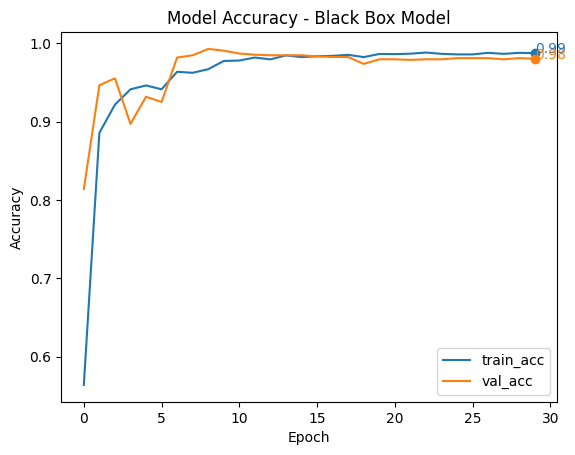

In [13]:
plt.plot(black_box.history.history['accuracy'], label='train_acc')
plt.plot(black_box.history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy - Black Box Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

for line in plt.gca().get_lines():
    xdata, ydata = line.get_xdata(), line.get_ydata()
    plt.scatter(xdata[-1], ydata[-1], color=line.get_color())
    plt.text(xdata[-1], ydata[-1], f'{ydata[-1]:.2f}', color=line.get_color())

plt.savefig('figures/black_box_acc.pdf', bbox_inches='tight')
plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step


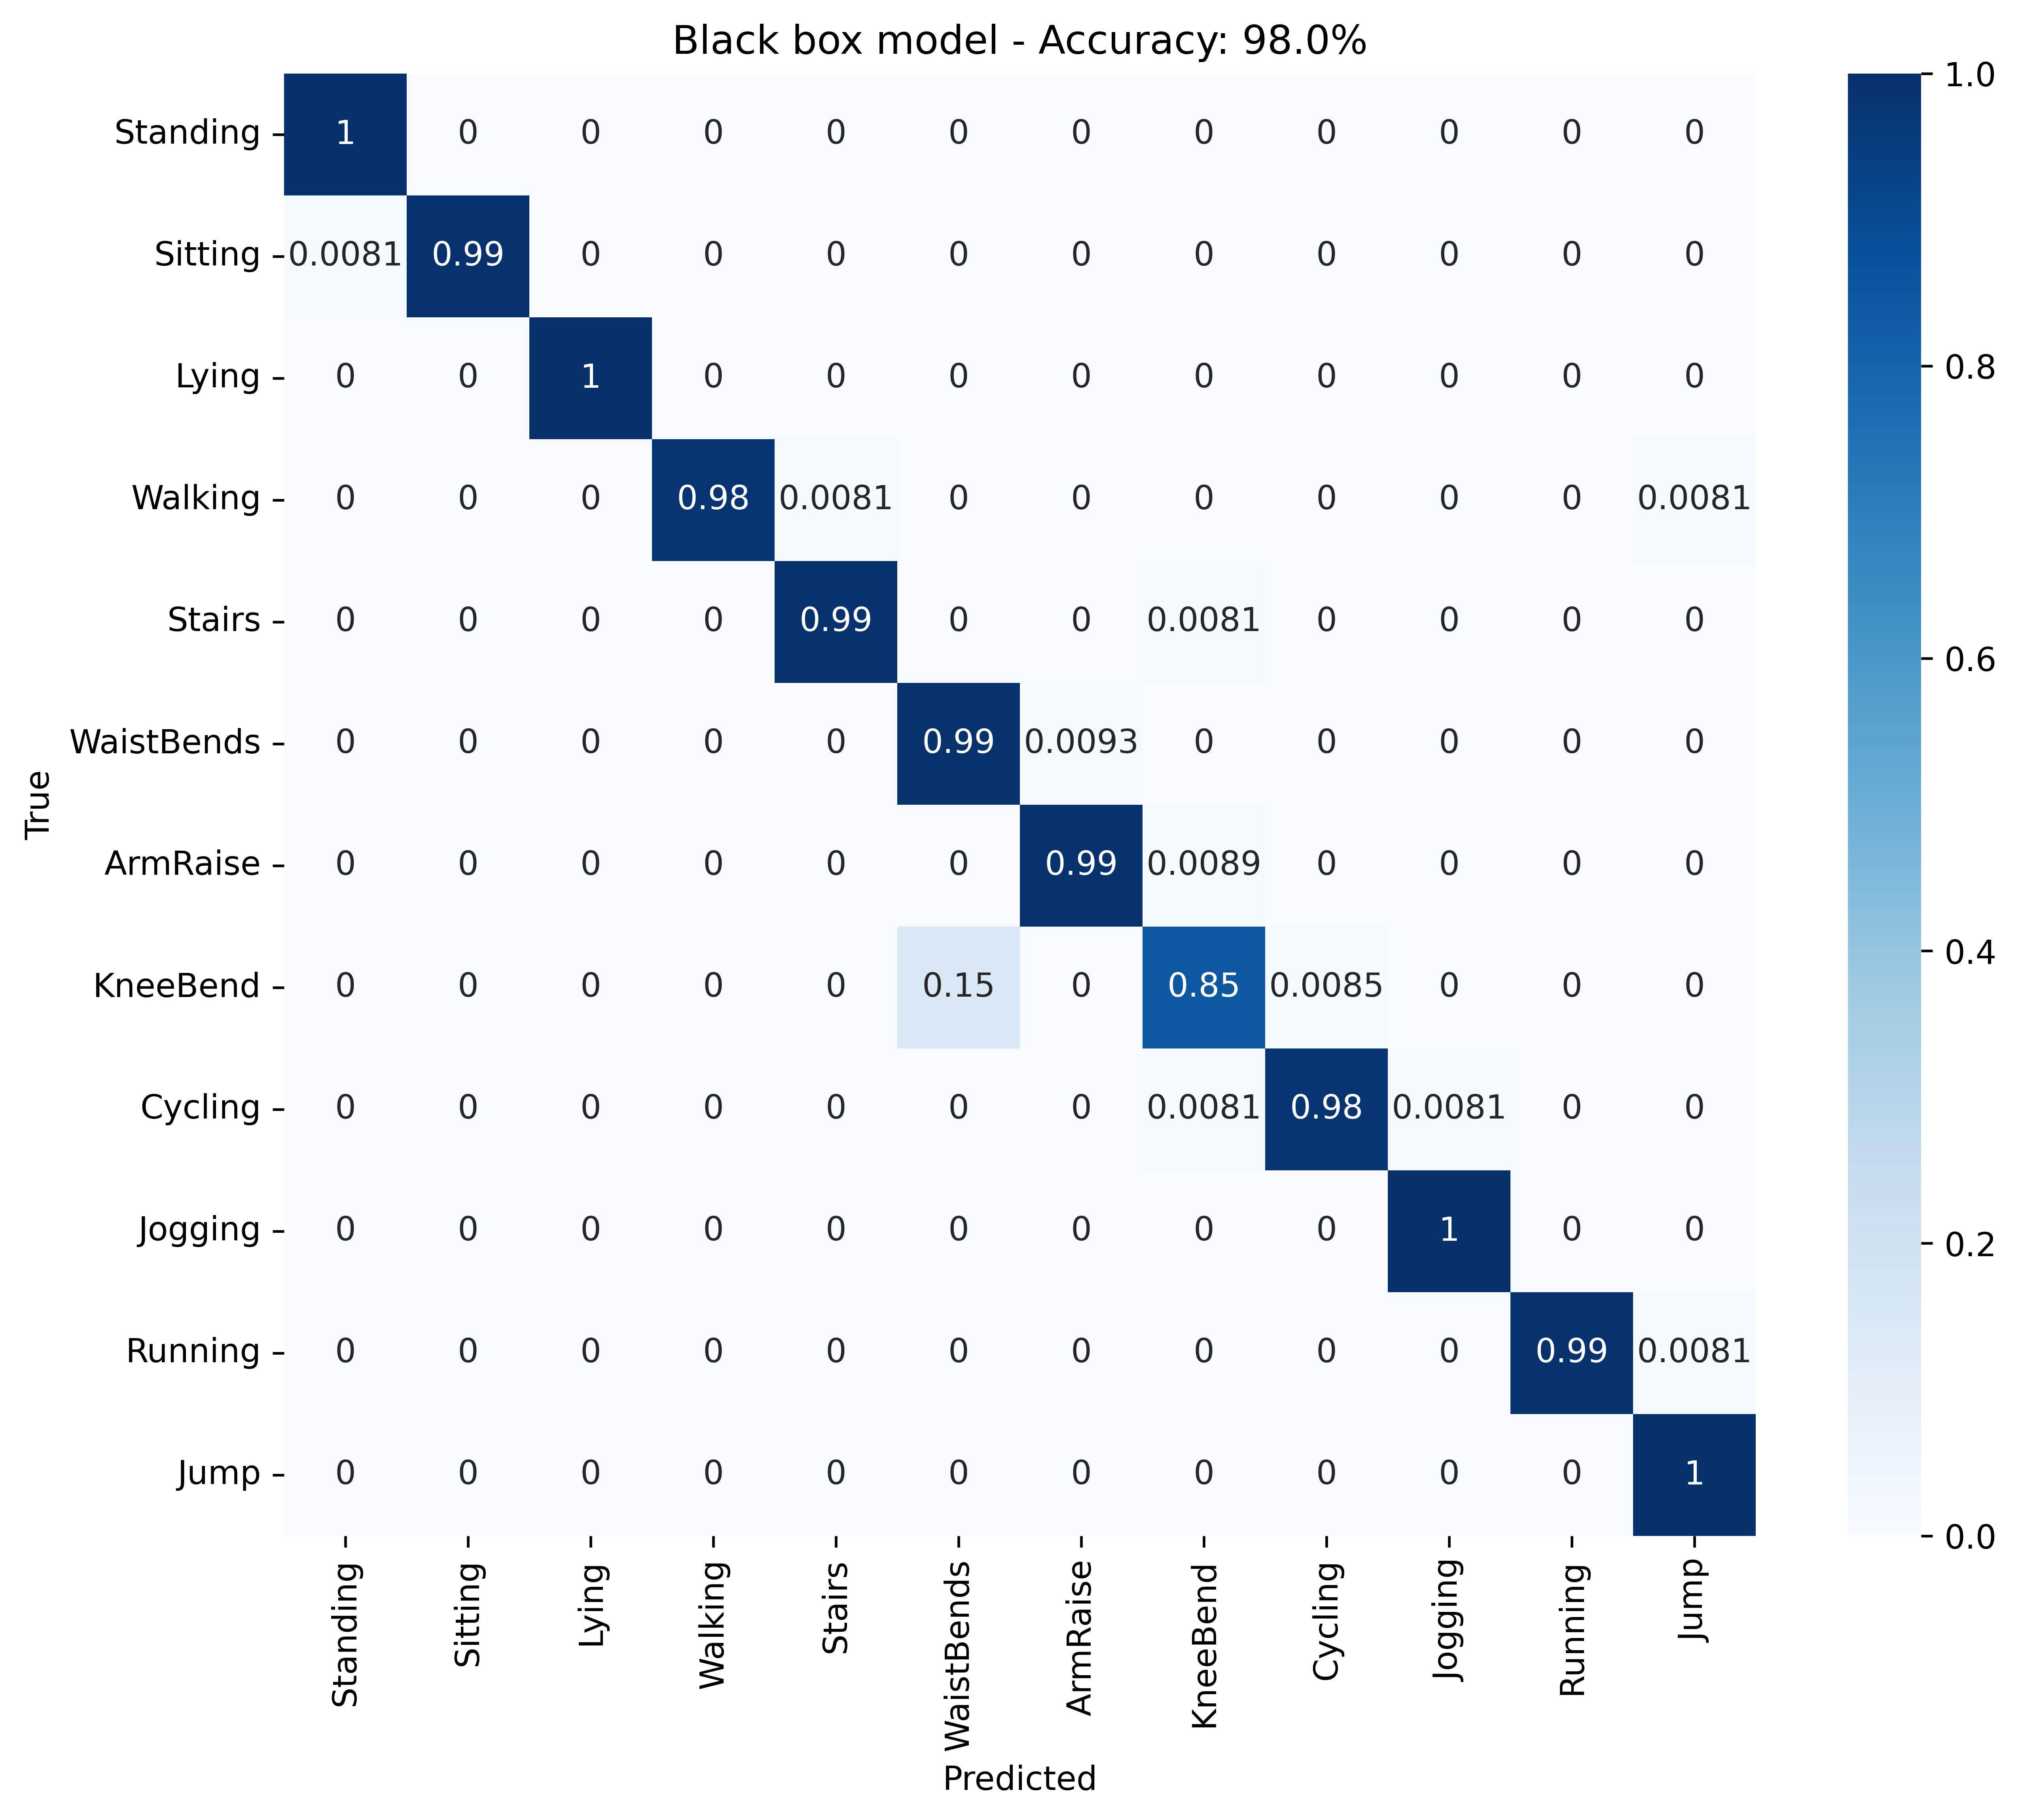

In [14]:
predictions = black_box.predict(test_sensors_groups)
predictions = np.argmax(predictions, axis=-1)

acc = accuracy_score(test_labels, predictions) * 100

cm = confusion_matrix(test_labels, predictions, normalize='true')

plt.figure(figsize=(10, 8), dpi=600)
sns.heatmap(cm, annot=True, fmt='.2g', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Black box model - Accuracy: %.1f' % acc + '%')
plt.savefig('figures/black_box_cm.pdf', bbox_inches='tight')
plt.show()